# Titanic Survival Analysis
## Can we determine who survived based on passenger data?

The RMS Titanic sank on April 15, 1912, after hitting an iceberg.
Of 2,224 passengers and crew, only 710 survived.

This analysis explores the 891 passenger training dataset to 
uncover what factors determined survival.

**Questions we'll answer:**
- What was the overall survival rate?
- Did gender affect survival?
- Did passenger class affect survival?
- Did age and fare play a role?
- Which group had the best and worst survival chances?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv(r"C:\Users\HP\AI-Learning\day-04\train.csv")

print(f"Columns: {list(df.columns)}")

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [3]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (891, 12)


The dataset contains 891 rows (passengers) and 12 columns (features).

Each row represents a passenger, and each column represents a feature such as age, gender, class, fare, etc.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


- The dataset contains a mix of numerical and categorical features.
- Data types include integers (e.g., Pclass), floats (e.g., Age, Fare), and objects (e.g., Name, Sex).

## Data Overview
The dataset has 891 passengers and 12 features including
survival status, passenger class, name, sex, age, 
family members aboard, ticket fare, and port of embarkation.

In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


- The average passenger age is around 29 years, with ages ranging from infants to 80 years.
- The survival rate is approximately 38%.
- The average fare is around 32, but the large standard deviation indicates high variability.
- The median fare aprox.(14.45) is much lower than the maximum fare aprox.(512), suggesting the presence of high-value outliers.
- Age has missing values, as indicated by the lower count (714).

In [3]:
df.isnull().sum()
print(f"Missing data:{df.isnull().sum()}")

Missing data:PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [4]:
MissingPercentage =df.isnull().sum()/len(df)*100
print(f"Missing data mean:{MissingPercentage}")

Missing data mean:PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


## Missing Values
- **Age**: 19.9% missing — will fill with median age
- **Cabin**: 77.1% missing — too much to be useful, will drop
- **Embarked**: 0.2% missing — only 2 rows, will drop those rows
- All other columns: complete, no missing values

In [5]:
df['Age']=df['Age'].fillna(df['Age'].median())
df = df.drop(columns=['Cabin'])
df=df.dropna(subset=['Embarked'])
df.isnull().sum()#checking

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## ❗ Missing Value Handling

The dataset contains missing values in the following columns:

- **Age (~19.9% missing)**  
  Missing values were filled using the **median age**.  
  The median is preferred over the mean because it is less affected by outliers and provides a more robust estimate for central tendency.

- **Embarked (~0.2% missing)**  
  Only a very small number of rows had missing values in this column.  
  These rows were **dropped** since removing them does not significantly impact the dataset.

- **Cabin (~77.1% missing)**  
  A large portion of this column is missing, making it unreliable for analysis.  
  Therefore, the entire column was **removed** instead of attempting imputation.

After handling missing values, the dataset is cleaner and more suitable for analysis.


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 83.3+ KB


### Finding 1 — Overall Survival

This shows the distribution of passengers who survived vs those who did not.


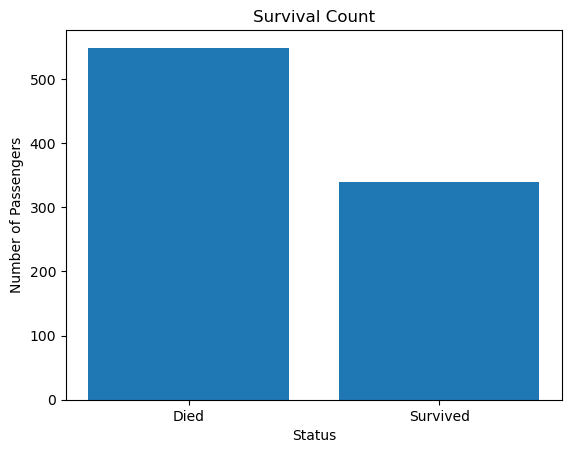

Survival rate: 0.38245219347581555


In [14]:
A = df['Survived'].value_counts()
B=df['Survived'].mean()
plt.bar(['Died', 'Survived'], A.values)
plt.title("Survival Count")
plt.xlabel("Status")
plt.ylabel("Number of Passengers")
plt.show()
print(f"Survival rate: {B}")

Only around 38% of passengers survived, indicating a high fatality rate.

### Finding 2 — Gender and Survival

Analyzing survival rate based on gender.

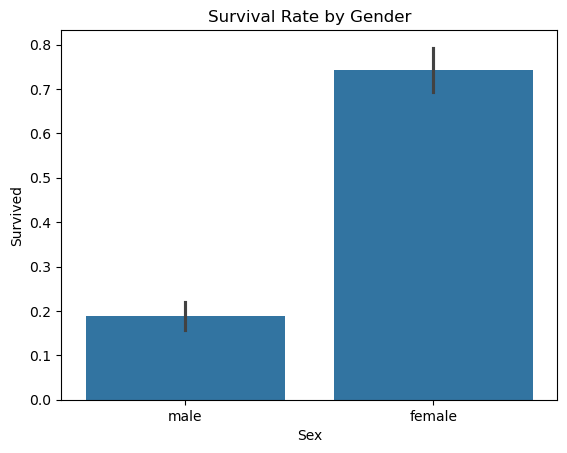

In [31]:
df.groupby('Sex')['Survived'].mean()

sns.barplot(x='Sex', y='Survived', data=df)
plt.title("Survival Rate by Gender")
plt.show()

Women had a significantly higher survival rate aprox.(74%) compared to men aprox.(19%).
This suggests that gender was one of the strongest factors influencing survival.

### Finding 3 — Passenger Class and Survival

Analyzing how passenger class affected survival.


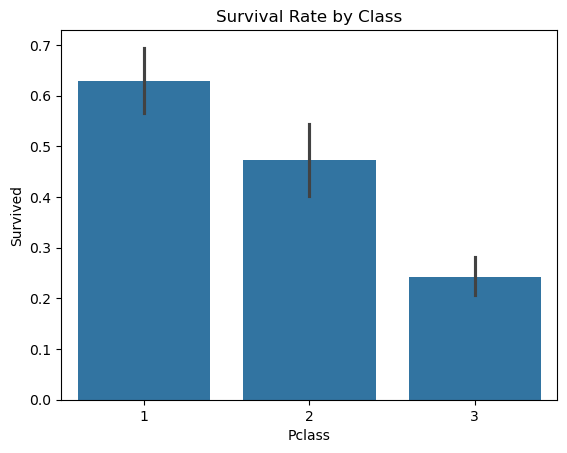

In [32]:
df.groupby('Pclass')['Survived'].mean()

sns.barplot(x='Pclass', y='Survived', data=df)
plt.title("Survival Rate by Class")
plt.show()

Passengers in 1st class had the highest survival rate, while those in 3rd class had the lowest.
This indicates that socio-economic status played a major role in survival.

### Finding 4 — Age Distribution

Comparing age distribution of survivors vs non-survivors.

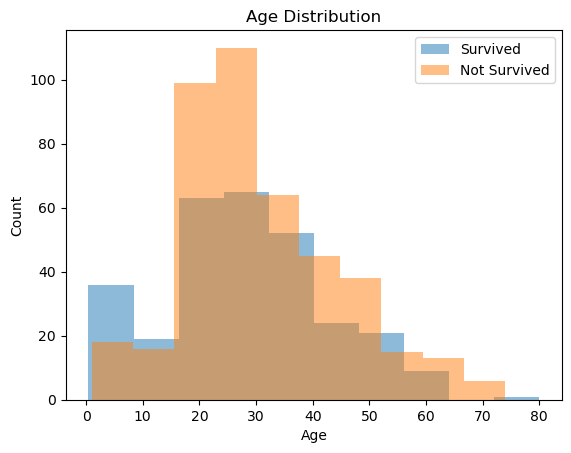

In [34]:
plt.hist(df[df['Survived']==1]['Age'], alpha=0.5, label='Survived')
plt.hist(df[df['Survived']==0]['Age'], alpha=0.5, label='Not Survived')
plt.legend()
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

There is a slight tendency for younger passengers to survive more, but the overlap is large.
Age alone is not a strong predictor of survival.

### Finding 5 — Fare and Survival

Analyzing how ticket fare relates to survival.

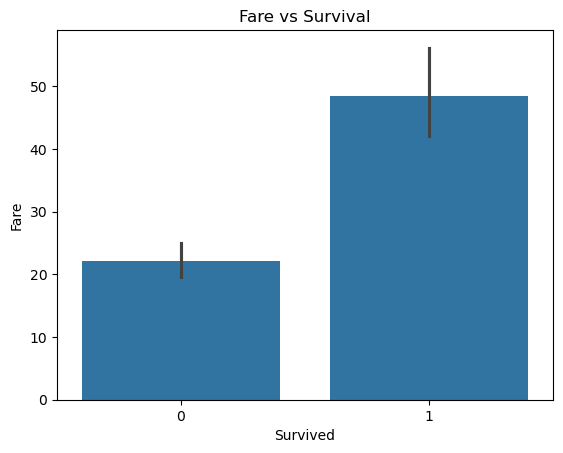

In [35]:
df.groupby('Survived')['Fare'].mean()

sns.barplot(x='Survived', y='Fare', data=df)
plt.title("Fare vs Survival")
plt.show()


Passengers who paid higher fares had better survival rates.
This is likely linked to passenger class and access to better facilities.

### Finding 6 — Gender and Class Combined

Analyzing combined effect of gender and passenger class.

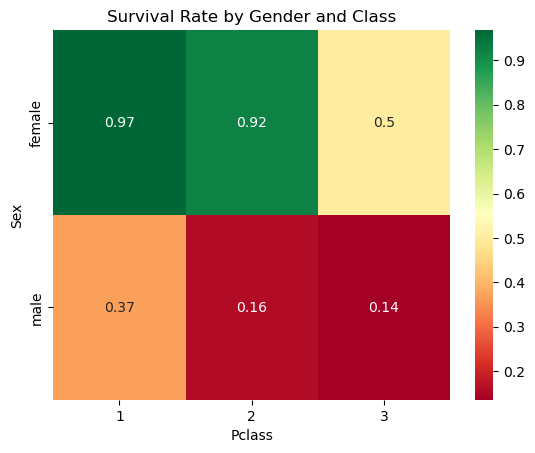

In [36]:
survival_pivot = df.pivot_table(values='Survived', 
                                index='Sex', 
                                columns='Pclass', 
                                aggfunc='mean')

sns.heatmap(survival_pivot, annot=True, cmap='RdYlGn')
plt.title("Survival Rate by Gender and Class")
plt.show()

Women in 1st class had the highest survival rate, while men in 3rd class had the lowest.
This shows that combining features reveals stronger patterns than analyzing them individually.

### Finding 7 — Family Size

Analyzing impact of family size on survival.

In [39]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df.groupby('FamilySize')['Survived'].mean()

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

Passengers with small families tended to have better survival rates,
while very large families had lower survival chances.

## ✅ Conclusion

- **Top factors influencing survival** were **gender, passenger class, and fare**. Women and first-class passengers had significantly higher survival rates.

- **Gender had the strongest impact**, with female passengers having a much higher survival rate compared to males.

- **Passenger class was a major factor**, indicating that socio-economic status affected access to safety and survival chances.

- **Surprising insight:** Age was not as strong a predictor as expected, despite common assumptions like "children first".

- **Further investigation:** Build a predictive model using these features and explore feature engineering (e.g., titles from names, deck from cabin, etc.) to improve accuracy.